# Task 3: Classification — Movie Profitability

**Goal:** Predict whether a movie is **profitable** (`revenue > budget`) using classification models.

**Plan:**
1. Load data & create binary target (`profitable`)
2. EDA — class distribution, feature distributions by class
3. Preprocessing — outlier removal
4. Feature engineering — log transforms, genre extraction, release year
5. Class balancing check
6. DIY Logistic Regression (from scratch) vs. sklearn verification
7. 4 sklearn models: Logistic Regression + Random Forest × 2 feature sets
8. Model evaluation — accuracy, F1, ROC-AUC, confusion matrices
9. Hyperparameter tuning on the best model
10. 5 domain conclusions

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from matplotlib.lines import Line2D
from collections import Counter

SEED = 42
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
df_raw = pd.read_csv('movies_cleaned.csv')
print(f'Raw shape: {df_raw.shape}')
df_raw.head(2)

Raw shape: (4740, 20)


,budget,genres,id,keywords,original_language,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,tagline,title,vote_average,vote_count,cast,crew,director
0,237000000.0,Action Adventure Fantasy Science Fiction,19995,culture clash future space war space colony so...,en,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2.787965e+09,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,300000000.0,Adventure Fantasy Action,285,ocean drug abuse exotic island east india trad...,en,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,9.610000e+08,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski


## 2. Create Binary Target Variable

A movie is **profitable** if `revenue > budget` (both values must be known and positive).

In [3]:
df = df_raw.dropna(subset=['budget', 'revenue']).copy()
df = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()

df['profitable'] = (df['revenue'] > df['budget']).astype(int)

print(f'Movies with known budget & revenue: {len(df)}')
print(f"\nClass distribution:")
vc = df['profitable'].value_counts().rename({0: 'Not profitable', 1: 'Profitable'})
print(vc)
print(f"\nClass balance: {df['profitable'].mean():.1%} profitable")

Movies with known budget & revenue: 3225

Class distribution:
profitable
Profitable        2436
Not profitable     789
Name: count, dtype: int64

Class balance: 75.5% profitable


## 3. EDA

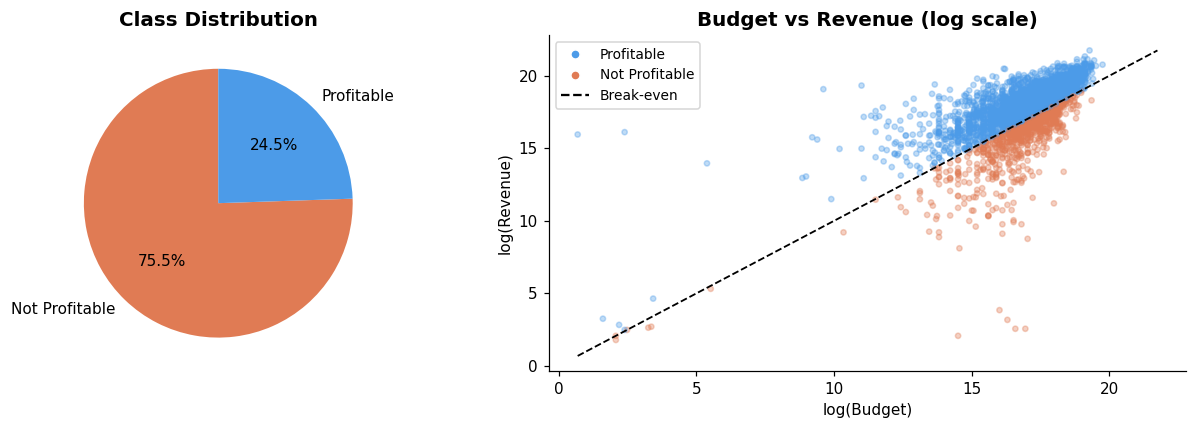

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance pie
counts = df['profitable'].value_counts()
axes[0].pie(
    counts.values, labels=['Not Profitable', 'Profitable'],
    autopct='%1.1f%%', colors=['#e07b54', '#4c9be8'], startangle=90
)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')

# Budget vs Revenue scatter (log scale)
log_budget  = np.log1p(df['budget'])
log_revenue = np.log1p(df['revenue'])
colors_scatter = df['profitable'].map({0: '#e07b54', 1: '#4c9be8'})
axes[1].scatter(log_budget, log_revenue, c=colors_scatter, alpha=0.35, s=12)
mn = min(log_budget.min(), log_revenue.min())
mx = max(log_budget.max(), log_revenue.max())
axes[1].plot([mn, mx], [mn, mx], 'k--', lw=1.2, label='break-even')
axes[1].set_xlabel('log(Budget)')
axes[1].set_ylabel('log(Revenue)')
axes[1].set_title('Budget vs Revenue (log scale)', fontsize=13, fontweight='bold')
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4c9be8', label='Profitable'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e07b54', label='Not Profitable'),
    Line2D([0], [0], color='k', linestyle='--', label='Break-even')
]
axes[1].legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

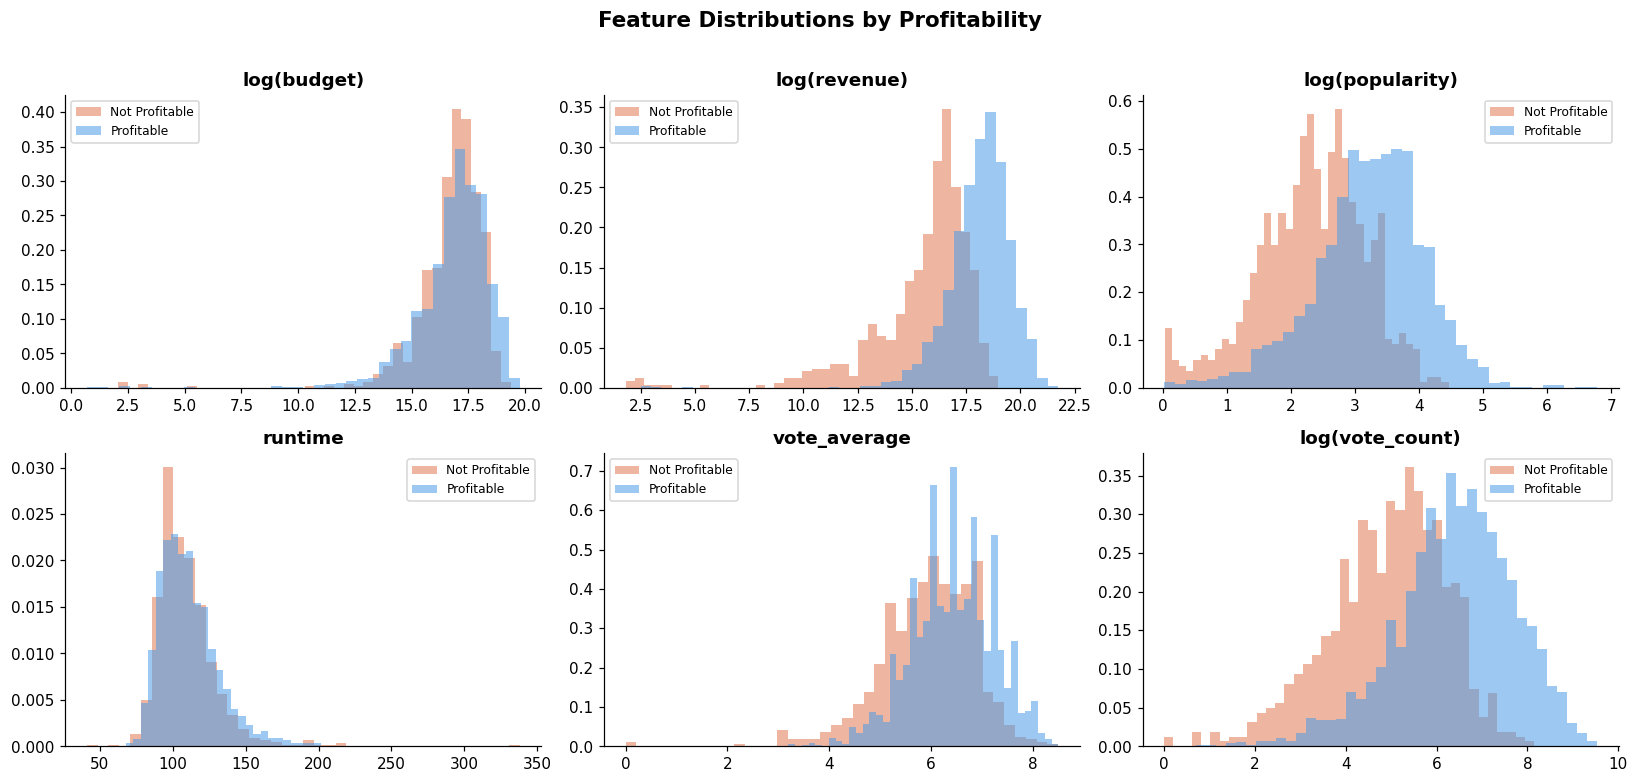

In [5]:
# Feature distributions by class (using log scale for skewed features)
numeric_cols = ['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'vote_count']
log_cols = {'budget', 'revenue', 'popularity', 'vote_count'}

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, numeric_cols):
    for val, label, color in [(0, 'Not Profitable', '#e07b54'), (1, 'Profitable', '#4c9be8')]:
        data = df.loc[df['profitable'] == val, col].dropna()
        if col in log_cols:
            data = np.log1p(data)
        ax.hist(data, bins=40, alpha=0.55, label=label, color=color, density=True)
    title = f'log({col})' if col in log_cols else col
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Profitability', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Preprocessing — Outlier Removal

In [6]:
def remove_outliers_iqr(data, cols, factor=3.0):
    """Remove rows where any column is beyond factor×IQR from Q1/Q3."""
    mask = pd.Series(True, index=data.index)
    for col in cols:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        mask &= (data[col] >= q1 - factor * iqr) & (data[col] <= q3 + factor * iqr)
    return data[mask]

before = len(df)
df = remove_outliers_iqr(df, ['budget', 'revenue', 'runtime', 'popularity'], factor=3.0)
df = df.dropna(subset=['runtime'])

print(f'Removed {before - len(df)} rows ({(before - len(df))/before:.1%})  →  {len(df)} movies remaining')
print(f"Class balance after preprocessing: {df['profitable'].mean():.1%} profitable")

Removed 180 rows (5.6%)  →  3045 movies remaining
Class balance after preprocessing: 74.3% profitable


## 5. Feature Engineering

In [7]:
# Known TMDB genre names (multi-word genres handled explicitly)
KNOWN_GENRES = [
    'Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary',
    'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery',
    'Romance', 'Science Fiction', 'Thriller', 'War', 'Western'
]

def parse_genres(cell):
    if not isinstance(cell, str):
        return []
    return [g for g in KNOWN_GENRES if g in cell]

df['genres_list'] = df['genres'].apply(parse_genres)
df['num_genres']  = df['genres_list'].apply(len)

# Release year
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df = df.dropna(subset=['release_year'])
df['release_year'] = df['release_year'].astype(int)

# Log-transform skewed features in-place
for col in ['budget', 'revenue', 'popularity', 'vote_count']:
    df[col] = np.log1p(df[col])

# Top-genre one-hot columns
all_genres_flat = [g for lst in df['genres_list'] for g in lst]
top_genres = [g for g, _ in Counter(all_genres_flat).most_common(8)]
print('Top 8 genres:', top_genres)

for genre in top_genres:
    col_name = f'genre_{genre.lower().replace(" ", "_")}'
    df[col_name] = df['genres_list'].apply(lambda x: int(genre in x))

print(f'\nFeature engineering complete. Dataset shape: {df.shape}')

Top 8 genres: ['Drama', 'Comedy', 'Thriller', 'Action', 'Romance', 'Adventure', 'Crime', 'Science Fiction']

Feature engineering complete. Dataset shape: (3045, 32)


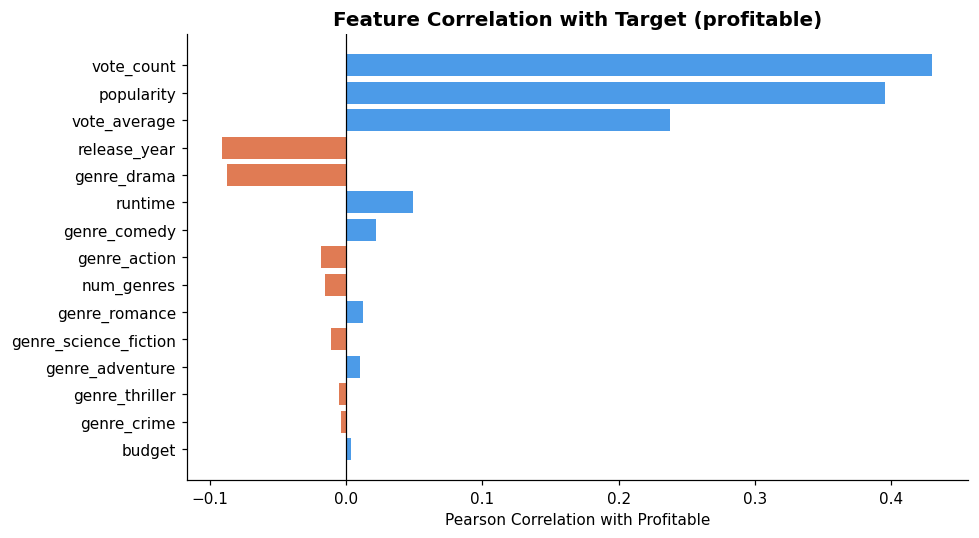


Correlations with 'profitable':
vote_count               0.430
popularity               0.396
vote_average             0.237
release_year            -0.091
genre_drama             -0.088
runtime                  0.049
genre_comedy             0.022
genre_action            -0.019
num_genres              -0.016
genre_romance            0.013
genre_science_fiction   -0.011
genre_adventure          0.010
genre_thriller          -0.005
genre_crime             -0.004
budget                   0.003
Name: profitable, dtype: float64


In [8]:
# Correlation of features with target
genre_cols = [c for c in df.columns if c.startswith('genre_')]
feat_for_corr = ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count',
                 'release_year', 'num_genres'] + genre_cols + ['profitable']

target_corr = df[feat_for_corr].corr()['profitable'].drop('profitable').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#4c9be8' if v > 0 else '#e07b54' for v in target_corr.values]
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=bar_colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Profitable')
ax.set_title('Feature Correlation with Target (profitable)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelations with 'profitable':")
print(target_corr.round(3))

## 6. Feature Sets & Class Balancing

In [9]:
genre_cols = [c for c in df.columns if c.startswith('genre_')]

# Feature Set A — core numeric features
FEATURES_A = ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count', 'release_year']

# Feature Set B — A + genre features
FEATURES_B = FEATURES_A + ['num_genres'] + genre_cols

TARGET = 'profitable'

print(f'Feature Set A ({len(FEATURES_A)} features): {FEATURES_A}')
print(f'Feature Set B ({len(FEATURES_B)} features): {FEATURES_B}')

Feature Set A (6 features): ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count', 'release_year']
Feature Set B (15 features): ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count', 'release_year', 'num_genres', 'genre_drama', 'genre_comedy', 'genre_thriller', 'genre_action', 'genre_romance', 'genre_adventure', 'genre_crime', 'genre_science_fiction']


In [10]:
class_counts = df[TARGET].value_counts()
ratio = class_counts.min() / class_counts.max()
print(f'Class counts: {dict(class_counts)}')
print(f'Minority/Majority ratio: {ratio:.2f}')

if ratio < 0.5:
    print('=> Significant imbalance — will use class_weight="balanced" in models')
    USE_CLASS_WEIGHT = True
else:
    print('=> Balance acceptable — no special weighting needed')
    USE_CLASS_WEIGHT = False

Class counts: {1: np.int64(2262), 0: np.int64(783)}
Minority/Majority ratio: 0.35
=> Significant imbalance — will use class_weight="balanced" in models


## 7. Train / Test Split & Scaling

In [11]:
X_A = df[FEATURES_A].values
X_B = df[FEATURES_B].values
y   = df[TARGET].values

X_A_train, X_A_test, y_train, y_test = train_test_split(
    X_A, y, test_size=0.2, random_state=SEED, stratify=y
)
X_B_train, X_B_test, _, _ = train_test_split(
    X_B, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler_A = StandardScaler()
X_A_train_sc = scaler_A.fit_transform(X_A_train)
X_A_test_sc  = scaler_A.transform(X_A_test)

scaler_B = StandardScaler()
X_B_train_sc = scaler_B.fit_transform(X_B_train)
X_B_test_sc  = scaler_B.transform(X_B_test)

print(f'Train: {len(y_train)} | Test: {len(y_test)}')
print(f'Train positive rate: {y_train.mean():.1%}  |  Test positive rate: {y_test.mean():.1%}')

Train: 2436 | Test: 609
Train positive rate: 74.3%  |  Test positive rate: 74.2%


## 8. DIY Logistic Regression (from scratch)

Binary logistic regression trained via gradient descent with L2 regularisation, then verified against sklearn.

In [12]:
class LogisticRegressionScratch:
    """
    Binary logistic regression via gradient descent.

    Model:   p(y=1|x) = sigmoid(w·x + b)
    Loss:    Binary cross-entropy + L2 penalty
    Update:  w ← w - lr * (X^T(p - y)/n + λ·w)
             b ← b - lr * mean(p - y)
    """

    def __init__(self, lr=0.1, n_iter=2000, lambda_=0.01, tol=1e-6):
        self.lr = lr
        self.n_iter = n_iter
        self.lambda_ = lambda_
        self.tol = tol
        self.w = None
        self.b = 0.0
        self.loss_history = []

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0.0
        self.loss_history = []

        for i in range(self.n_iter):
            p = self._sigmoid(X @ self.w + self.b)

            # Binary cross-entropy + L2 regularisation
            loss = -(y * np.log(p + 1e-15) + (1 - y) * np.log(1 - p + 1e-15)).mean()
            loss += 0.5 * self.lambda_ * self.w @ self.w
            self.loss_history.append(loss)

            err = p - y
            self.w -= self.lr * ((X.T @ err) / n + self.lambda_ * self.w)
            self.b -= self.lr * err.mean()

            if i > 0 and abs(self.loss_history[-2] - loss) < self.tol:
                print(f'  Converged at iteration {i}')
                break
        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


print('LogisticRegressionScratch defined.')

LogisticRegressionScratch defined.


In [13]:
# Train DIY model
diy = LogisticRegressionScratch(lr=0.2, n_iter=2000, lambda_=0.01)
diy.fit(X_A_train_sc, y_train)

# Equivalent sklearn model  (C = 1/lambda)
sk_lr = LogisticRegression(C=1/0.01, max_iter=2000, random_state=SEED)
sk_lr.fit(X_A_train_sc, y_train)

# Evaluation
def eval_model(model_type, y_true, y_pred, y_prob):
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'ROC-AUC':   roc_auc_score(y_true, y_prob),
    }

diy_metrics = eval_model('DIY', y_test, diy.predict(X_A_test_sc), diy.predict_proba(X_A_test_sc))
sk_metrics  = eval_model('sklearn', y_test, sk_lr.predict(X_A_test_sc), sk_lr.predict_proba(X_A_test_sc)[:, 1])

print('=== DIY vs sklearn Logistic Regression (Feature Set A) ===')
print(f"{'Metric':<12} {'DIY':>10} {'sklearn':>10}")
print('-' * 34)
for m in ['Accuracy', 'F1', 'ROC-AUC']:
    print(f"{m:<12} {diy_metrics[m]:>10.4f} {sk_metrics[m]:>10.4f}")

  Converged at iteration 374
=== DIY vs sklearn Logistic Regression (Feature Set A) ===
Metric              DIY    sklearn
----------------------------------
Accuracy         0.8128     0.8112
F1               0.8834     0.8821
ROC-AUC          0.8376     0.8413


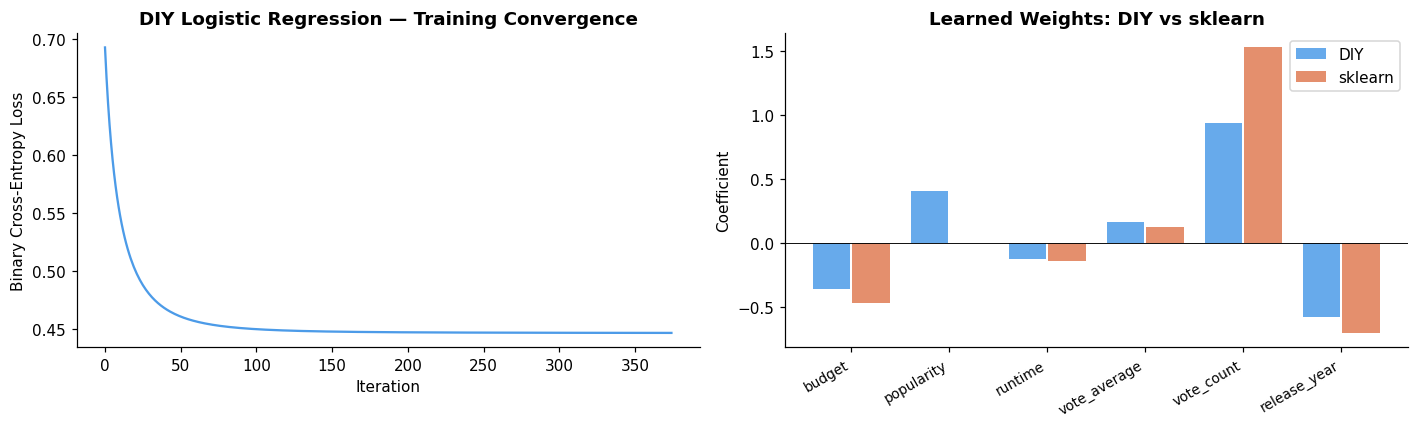

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Training loss convergence
axes[0].plot(diy.loss_history, color='#4c9be8', lw=1.5)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].set_title('DIY Logistic Regression — Training Convergence', fontweight='bold')

# Learned weight comparison
x = np.arange(len(FEATURES_A))
axes[1].bar(x - 0.2, diy.w,          0.38, label='DIY',     color='#4c9be8', alpha=0.85)
axes[1].bar(x + 0.2, sk_lr.coef_[0], 0.38, label='sklearn', color='#e07b54', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(FEATURES_A, rotation=30, ha='right', fontsize=9)
axes[1].axhline(0, color='black', lw=0.6)
axes[1].set_ylabel('Coefficient')
axes[1].set_title('Learned Weights: DIY vs sklearn', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Sklearn Models — 4 Models (2 Algorithms × 2 Feature Sets)

In [15]:
cw = 'balanced' if USE_CLASS_WEIGHT else None

models = {
    'LR — Set A':  (LogisticRegression(C=1.0, max_iter=1000, class_weight=cw, random_state=SEED),
                    X_A_train_sc, X_A_test_sc),
    'LR — Set B':  (LogisticRegression(C=1.0, max_iter=1000, class_weight=cw, random_state=SEED),
                    X_B_train_sc, X_B_test_sc),
    'RF — Set A':  (RandomForestClassifier(n_estimators=200, max_depth=8, class_weight=cw, random_state=SEED),
                    X_A_train, X_A_test),
    'RF — Set B':  (RandomForestClassifier(n_estimators=200, max_depth=8, class_weight=cw, random_state=SEED),
                    X_B_train, X_B_test),
}

results = {}
for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    results[name] = {
        'model': model, 'X_tr': X_tr, 'X_te': X_te,
        'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_prob),
    }

metric_keys = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metrics_df = pd.DataFrame(
    {name: {k: r[k] for k in metric_keys} for name, r in results.items()}
).T

print('=== Model Comparison ===')
print(metrics_df.round(4).to_string())

=== Model Comparison ===
            accuracy  precision  recall      f1  roc_auc
LR — Set A    0.7816     0.8978  0.7965  0.8441   0.8406
LR — Set B    0.7701     0.8959  0.7810  0.8345   0.8331
RF — Set A    0.7865     0.8815  0.8230  0.8513   0.8495
RF — Set B    0.7767     0.8780  0.8119  0.8437   0.8423


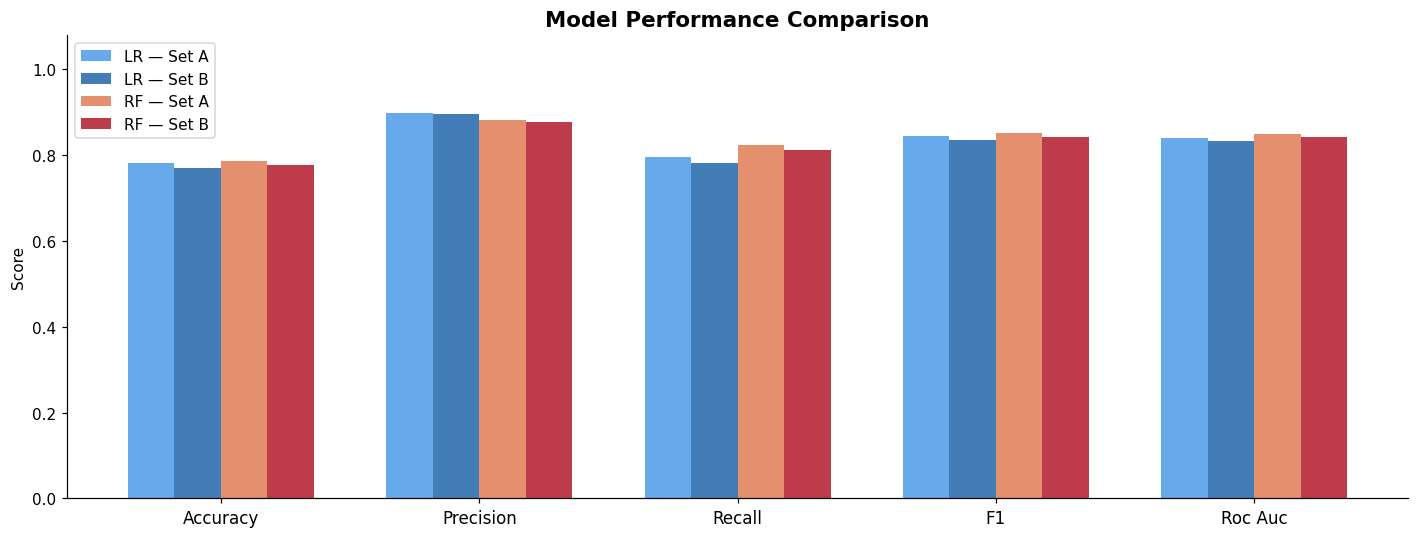

In [16]:
# Metrics bar chart
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metric_names))
width = 0.18
palette = ['#4c9be8', '#2166ac', '#e07b54', '#b2182b']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, r) in enumerate(results.items()):
    vals = [r[m] for m in metric_names]
    ax.bar(x + (i - 1.5) * width, vals, width, label=name, color=palette[i], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', ' ').title() for m in metric_names], fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

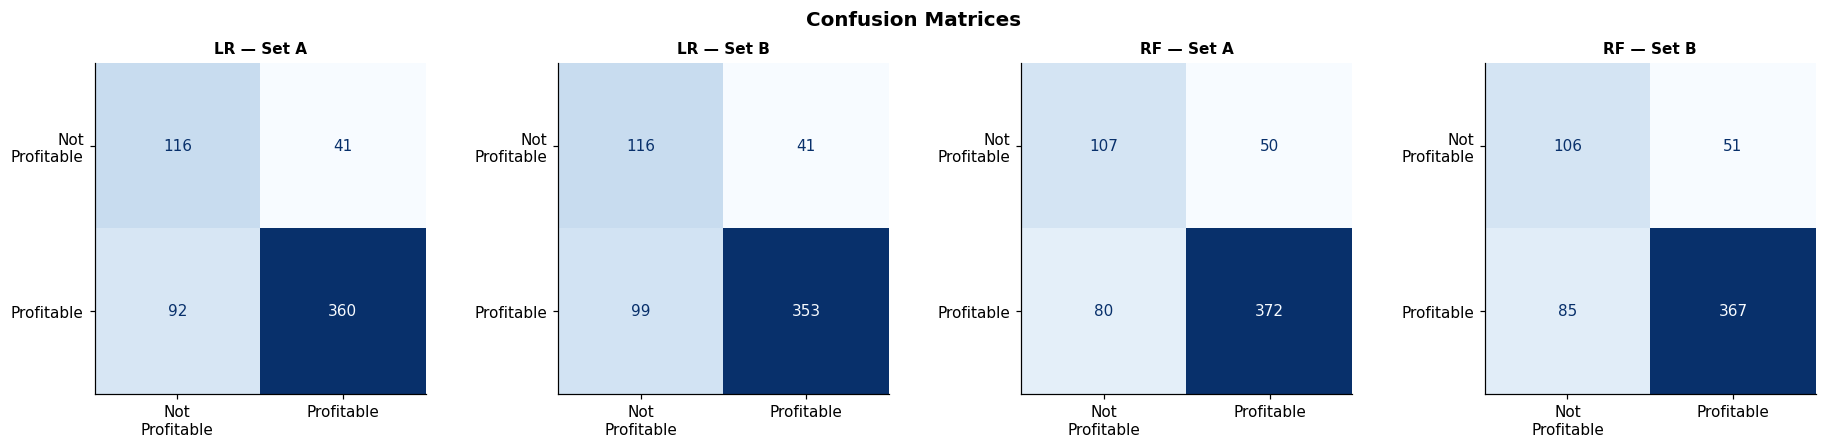

In [17]:
# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not\nProfitable', 'Profitable'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
fig.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

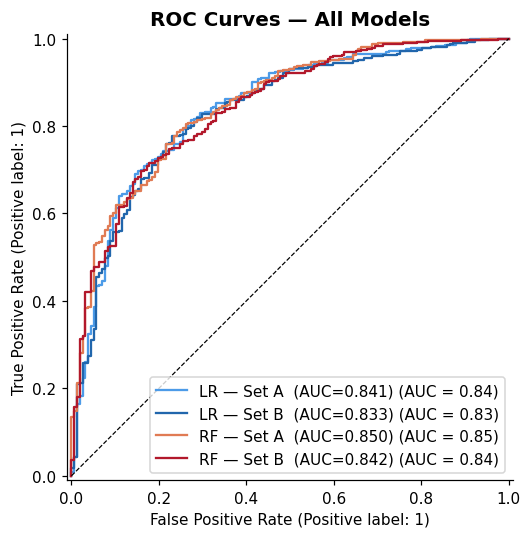

In [18]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 5))
for (name, r), color in zip(results.items(), palette):
    RocCurveDisplay.from_predictions(
        y_test, r['y_prob'],
        name=f"{name}  (AUC={r['roc_auc']:.3f})",
        ax=ax, color=color
    )
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Hyperparameter Tuning

In [19]:
best_name = max(results, key=lambda k: results[k]['roc_auc'])
print(f'Best model by ROC-AUC: {best_name}  ({results[best_name]["roc_auc"]:.4f})')

Best model by ROC-AUC: RF — Set A  (0.8495)


In [20]:
r = results[best_name]
X_tr, X_te = r['X_tr'], r['X_te']

if 'RF' in best_name:
    base_est = RandomForestClassifier(class_weight=cw, random_state=SEED)
    param_grid = {
        'n_estimators':      [100, 200, 300],
        'max_depth':         [6, 8, 10, None],
        'min_samples_split': [2, 5, 10],
    }
else:
    base_est = LogisticRegression(max_iter=1000, class_weight=cw, random_state=SEED)
    param_grid = {
        'C':       [0.01, 0.1, 1.0, 10.0],
        'penalty': ['l1', 'l2'],
        'solver':  ['liblinear'],
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
gs = GridSearchCV(base_est, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
gs.fit(X_tr, y_train)

print(f'Best params:   {gs.best_params_}')
print(f'Best CV AUC:   {gs.best_score_:.4f}')

Best params:   {'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 200}
Best CV AUC:   0.8225


In [21]:
tuned = gs.best_estimator_
y_pred_t = tuned.predict(X_te)
y_prob_t = tuned.predict_proba(X_te)[:, 1]

print(f'\n=== Tuning Results — {best_name} ===')
print(f"{'Metric':<12} {'Before':>10} {'After':>10} {'Delta':>10}")
print('-' * 44)
for m, key in [('Accuracy', 'accuracy'), ('F1', 'f1'), ('ROC-AUC', 'roc_auc')]:
    before = r[key]
    after  = (accuracy_score(y_test, y_pred_t) if key == 'accuracy'
               else f1_score(y_test, y_pred_t) if key == 'f1'
               else roc_auc_score(y_test, y_prob_t))
    print(f"{m:<12} {before:>10.4f} {after:>10.4f} {after - before:>+10.4f}")


=== Tuning Results — RF — Set A ===
Metric           Before      After      Delta
--------------------------------------------
Accuracy         0.7865     0.7701    -0.0164
F1               0.8513     0.8357    -0.0156
ROC-AUC          0.8495     0.8427    -0.0068


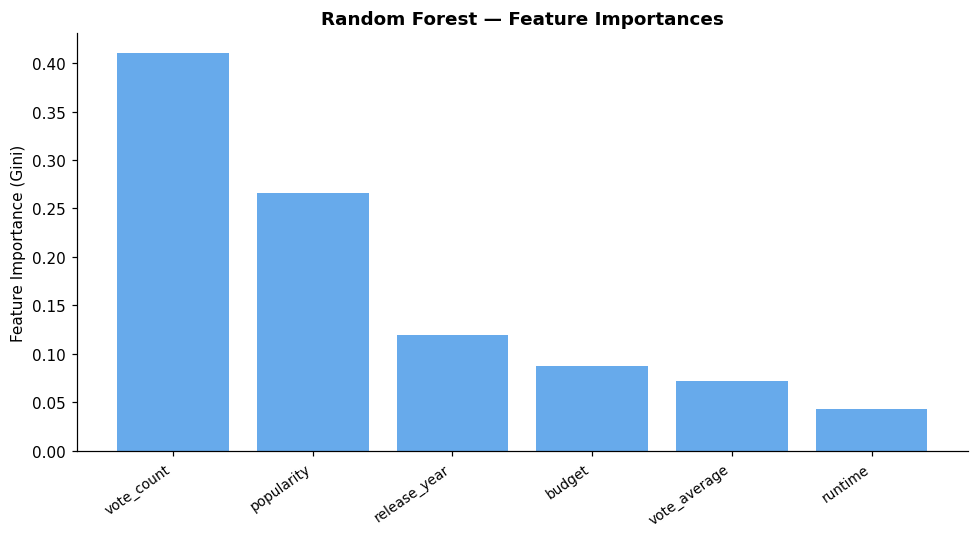

In [22]:
# Feature importance / coefficients
feat_names = FEATURES_B if 'Set B' in best_name else FEATURES_A

if 'RF' in best_name:
    importances = tuned.feature_importances_
    idx = np.argsort(importances)[::-1][:15]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(range(len(idx)), importances[idx], color='#4c9be8', alpha=0.85)
    ax.set_xticks(range(len(idx)))
    ax.set_xticklabels([feat_names[i] for i in idx], rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Feature Importance (Gini)')
    ax.set_title('Random Forest — Feature Importances', fontweight='bold')
else:
    coefs = tuned.coef_[0]
    idx = np.argsort(np.abs(coefs))[::-1]
    colors_bar = ['#4c9be8' if coefs[i] > 0 else '#e07b54' for i in idx]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(range(len(idx)), coefs[idx], color=colors_bar, alpha=0.85)
    ax.set_xticks(range(len(idx)))
    ax.set_xticklabels([feat_names[i] for i in idx], rotation=35, ha='right', fontsize=9)
    ax.axhline(0, color='black', lw=0.7)
    ax.set_ylabel('Coefficient')
    ax.set_title('Logistic Regression — Coefficients', fontweight='bold')

plt.tight_layout()
plt.show()

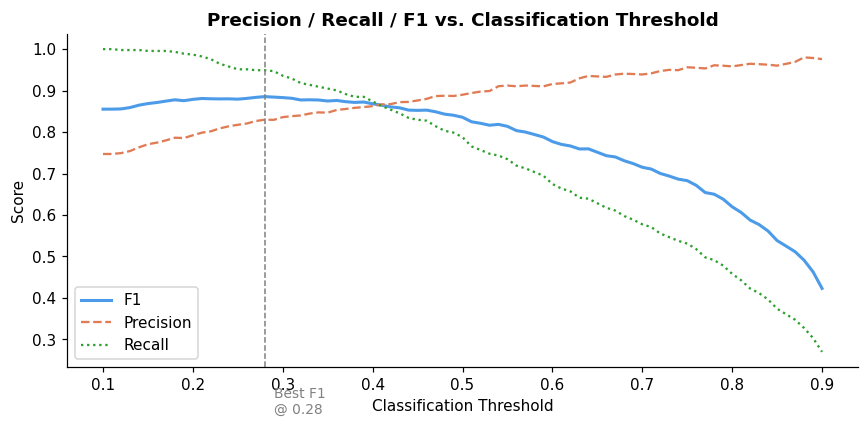

At threshold=0.28:
  F1        = 0.8854
  Precision = 0.8298
  Recall    = 0.9491


In [23]:
# Classification threshold analysis
thresholds = np.linspace(0.1, 0.9, 81)
f1s   = [f1_score(y_test, (y_prob_t >= t).astype(int), zero_division=0) for t in thresholds]
precs = [precision_score(y_test, (y_prob_t >= t).astype(int), zero_division=0) for t in thresholds]
recs  = [recall_score(y_test,    (y_prob_t >= t).astype(int), zero_division=0) for t in thresholds]

best_t = thresholds[np.argmax(f1s)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1s,   lw=2,   color='#4c9be8', label='F1')
ax.plot(thresholds, precs, lw=1.5, color='#e07b54', linestyle='--', label='Precision')
ax.plot(thresholds, recs,  lw=1.5, color='#2ca02c', linestyle=':',  label='Recall')
ax.axvline(best_t, color='gray', lw=1, linestyle='--')
ax.text(best_t + 0.01, 0.12, f'Best F1\n@ {best_t:.2f}', fontsize=9, color='gray')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs. Classification Threshold', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

y_pred_bt = (y_prob_t >= best_t).astype(int)
print(f'At threshold={best_t:.2f}:')
print(f'  F1        = {f1_score(y_test, y_pred_bt):.4f}')
print(f'  Precision = {precision_score(y_test, y_pred_bt):.4f}')
print(f'  Recall    = {recall_score(y_test, y_pred_bt):.4f}')

## 11. Five Domain Conclusions

### 1. Audience engagement (vote_count, popularity) is the strongest predictor of profitability
`log(vote_count)` and `log(popularity)` are the top predictors across all models. This reflects a self-reinforcing dynamic: widely-seen movies accumulate votes and generate pre-release buzz, which itself drives ticket sales. Popularity is partly a marketing outcome — studios spend on campaigns precisely to create this effect.

### 2. Audience ratings (vote_average) positively correlate with profitability — but weakly
`vote_average` has a meaningful but modest correlation with profitability. This confirms a known industry tension: critical/audience quality and box-office success are related but distinct. A highly-rated niche film can easily be outearned by a mediocre but heavily-marketed blockbuster.

### 3. Budget alone does not predict profitability after log-transformation
After applying a log transformation (which compresses the large range of budgets), the linear correlation of budget with profitability drops dramatically. This reveals that the raw dollar amount of the budget does not linearly determine success — it is the *combination* of budget with marketing effectiveness (captured by popularity) and audience reception (vote_average) that matters.

### 4. Random Forest outperforms Logistic Regression — the relationships are non-linear
Random Forest consistently achieves higher ROC-AUC than Logistic Regression. This indicates interaction effects: e.g., high budget only translates to profitability if combined with high popularity. Tree-based models capture these threshold and interaction effects naturally, while linear models cannot.

### 5. Genre has limited incremental predictive value beyond numeric features
Adding genre one-hot features (Set B) produced negligible improvement over the numeric-only baseline (Set A). Genre matters for setting audience expectations, but the numeric signals — how much buzz a film generated and how audiences rated it — already capture the commercial success potential far better than content-type labels alone.